### Python 과 JSON의 관계

1) Python 객체를 JSON 데이터로 쓰기, 직렬화, 인코딩
 - Write Python object to JSON, Serialization, Encoding
 
2) JSON 포맷 데이터를 Python 객체로 읽기, 역직렬화, 디코딩
 - Read JSON to Python, Deserialization, Decoding
 

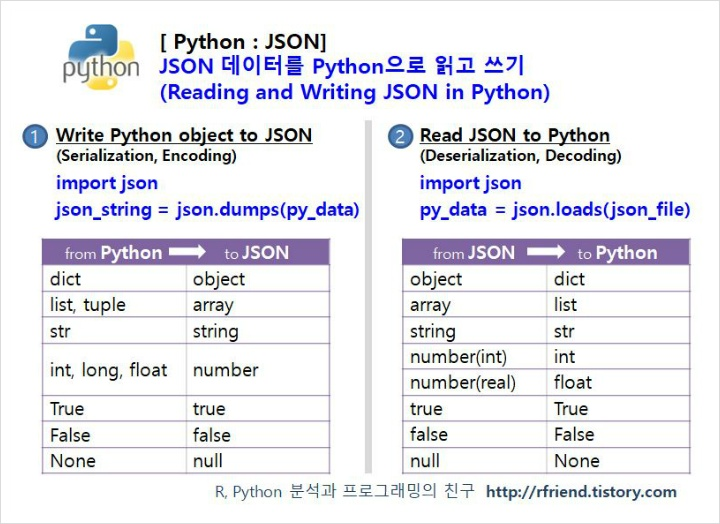

In [12]:
from IPython.display import Image
from IPython.display import display

Image("C:/Users/user/Jupyter_project/PythonandJson.png")

위 Python - JSON 간 변환 표에서 보는 바와 같이 
- Python의 list, tuple은 JSON의 array로 변환이 된다.
- 여기서 JSON의 array를 다시 Python의 list로 변환이 된다.
- 따라서 Python의 tuple을 JSON으로 변환하면, JSON array가 되며, 이를 다시 Python으로 변환하면 이땐 Python의 tuple이 아니라 list로 변환이 된다는 점을 인식해야 한다.
- 왜냐하면 list와 tuple 사이에는 수정 가능 / iterablilty의 차이가 있기 때문이다.

### Python 객체를 JSON 데이터로 쓰기, 직렬화, 인코딩하기

- json.dumps()
- Write Python object to JSON, Serialization, Encoding

In [13]:
# Python객체를 JSON 데이터로 만들어서 쓰기 위해서는 파이썬의 내장 json 모듈이 필요합니다.


import json

In [14]:
student_data={
    "1.FirstName":"Gildong",
    "2.LastName":"Hong",
    "3.Age":20,
    "4.University":"Yonsei University",
    #Courses라는 하나의 키에, 밸류를, 리스트로 집어넣은 형태입니다.
    "5.Courses":[
        #다시 또 분류를 해두었습니다.
        #Courses의 밸류인 리스트 안에 들어간 객체들이 또다시 딕셔너리가 됨.
        #복잡하지만 구조적으로 이해가 된다면 좋을 것 같아요.
        #1. 전공 
        {
            "Major": "Statistics",
            "Classes":["Probablility","Generalized Linear Model","Categorical Data Analysis"]
            
            
        },
        
        #2. 부전공 혹은 복수전공
        {
            "Minor": "ComputerScience",
            "Classes":["Data Structure","Programming","Algorithms"]
            
        }
        
    ]   
}

#### (2-1) with open() : json.dump()를 사용하여 JSON 포맷 데이터를 디스크에 쓰기

- with open("student_file.json","w")로 student_file.json 이름의 파일을 쓰기 모드로 열어놓고
- json.dump(student_data,json_file)로 직렬화해서, Json으로 내보내고자 하는 객체 student_data를, 직렬화된 데이터가 쓰여질 파일 json_file에 쓰기를 해주었습니다.

In [15]:
import json

with open("student_file.json","w") as json_file:
    
    json.dump(student_data,json_file)

** 이렇게 하면 student_data의 정보를 담은 student_file.json이라는 이름의 JSON 포맷 데이터가 새로 생성되었음을 볼 수 있습니다.

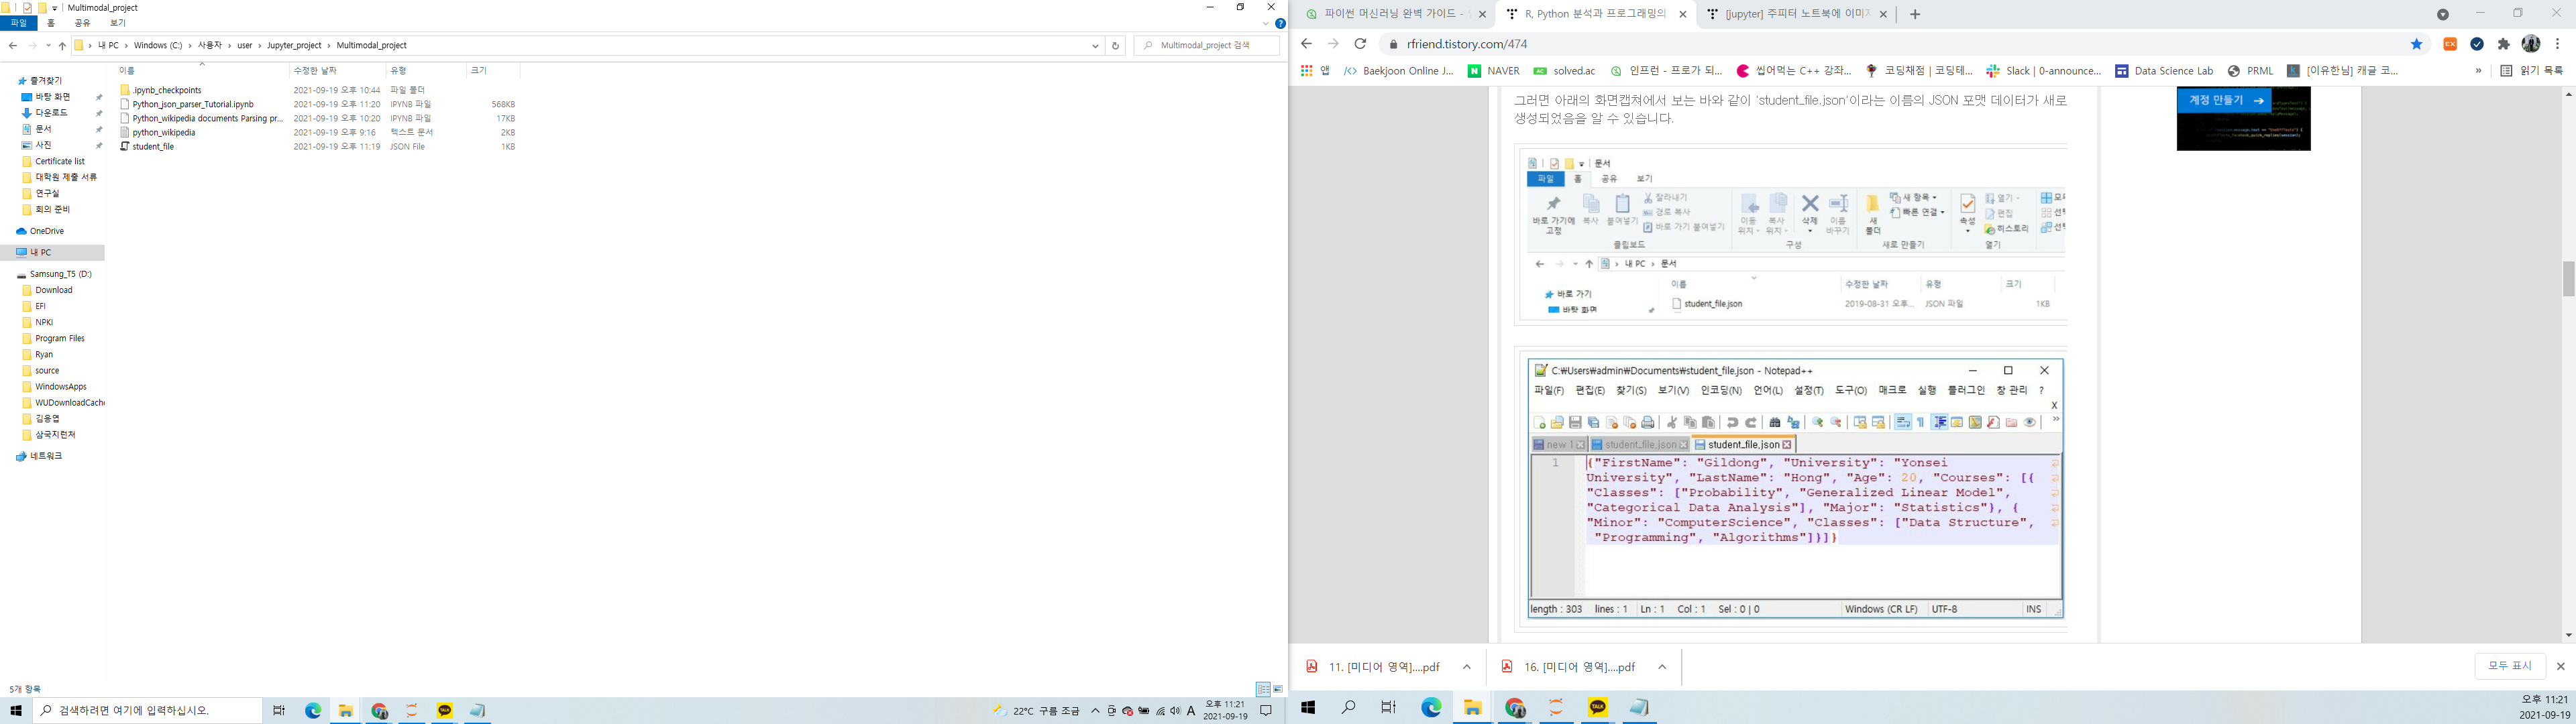

In [18]:
Image("C:/Users/user/Jupyter_project/res.png")

#### (2-2) json.dumps()를 사용해서 JSON 포맷 데이터를 메모리에 만들기

- json.dump()는 디스크에 저장하는 용도였다면
- json.dumps()는 메모리 상에 json 데이터를 만들어놓고, 그것을 python에서 계속 작업을 할 때 사용합니다.

In [19]:
import json

st_json = json.dumps(student_data)

print(st_json)

{"1.FirstName": "Gildong", "2.LastName": "Hong", "3.Age": 20, "4.University": "Yonsei University", "5.Courses": [{"Major": "Statistics", "Classes": ["Probablility", "Generalized Linear Model", "Categorical Data Analysis"]}, {"Minor": "ComputerScience", "Classes": ["Data Structure", "Programming", "Algorithms"]}]}


#### 가독성 이슈

- 직렬화된 json 객체를 더 사람이 보기 쉽게 만들도록
- indent 옵션을 설정할 수 있습니다.
- sort_keys=True 를 설정해주면 key를 기준으로 정렬, 직렬화하여 내보낼 수도 있습니다.


In [21]:
st_json = json.dumps(student_data,indent=4)

print(st_json)

{
    "1.FirstName": "Gildong",
    "2.LastName": "Hong",
    "3.Age": 20,
    "4.University": "Yonsei University",
    "5.Courses": [
        {
            "Major": "Statistics",
            "Classes": [
                "Probablility",
                "Generalized Linear Model",
                "Categorical Data Analysis"
            ]
        },
        {
            "Minor": "ComputerScience",
            "Classes": [
                "Data Structure",
                "Programming",
                "Algorithms"
            ]
        }
    ]
}


In [23]:
import json

st_json3 = json.dumps(student_data,indent=4,sort_keys=True)

print(st_json3)

{
    "1.FirstName": "Gildong",
    "2.LastName": "Hong",
    "3.Age": 20,
    "4.University": "Yonsei University",
    "5.Courses": [
        {
            "Classes": [
                "Probablility",
                "Generalized Linear Model",
                "Categorical Data Analysis"
            ],
            "Major": "Statistics"
        },
        {
            "Classes": [
                "Data Structure",
                "Programming",
                "Algorithms"
            ],
            "Minor": "ComputerScience"
        }
    ]
}


### JSON 포맷 데이터를 Python 객체로 읽기, 역직렬화, 디코딩 : json.loads()

- Read JSON to Python, Deserialization, Decoding

#### (2-1) 디스크에 있는 JSON 포맷 데이터를 json.load()를 사용하여 Python 객체로 읽어오는 과정입니다. (역직렬화, 디코딩하기)

- 이어서 (1)번에서 with open() : json.dump()로 만들어놓은 JSON 포맷의 데이터 "student_file.json"을 Python으로 역직렬화해서 읽어와 보겠습니다. 
- with open("student_file.json","r")로 읽기 모드로 json 파일을 열어본 후에 
- json.load(st_json)으로 디코딩하였습니다.

In [24]:
import json

with open("student_file.json","r") as st_json:
    
    st_python = json.load(st_json)
    

st_python

{'1.FirstName': 'Gildong',
 '2.LastName': 'Hong',
 '3.Age': 20,
 '4.University': 'Yonsei University',
 '5.Courses': [{'Major': 'Statistics',
   'Classes': ['Probablility',
    'Generalized Linear Model',
    'Categorical Data Analysis']},
  {'Minor': 'ComputerScience',
   'Classes': ['Data Structure', 'Programming', 'Algorithms']}]}

#### (2-2) 메모리에 있는 JSON 포맷 데이터를 json.loads()로 Python 객체로 읽기 
- 역직렬화, 디코딩

In [25]:
import json

st_python2 = json.loads(st_json3)

st_python2

{'1.FirstName': 'Gildong',
 '2.LastName': 'Hong',
 '3.Age': 20,
 '4.University': 'Yonsei University',
 '5.Courses': [{'Classes': ['Probablility',
    'Generalized Linear Model',
    'Categorical Data Analysis'],
   'Major': 'Statistics'},
  {'Classes': ['Data Structure', 'Programming', 'Algorithms'],
   'Minor': 'ComputerScience'}]}